##### Установка необходимых библиотек

In [1]:
# Зеркало Tsinghua University
!pip install pandas numpy matplotlib scikit-learn torch \
  -i https://pypi.tuna.tsinghua.edu.cn/simple \
  --default-timeout=100

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


##### Импорты, фиксация seed и определение устройства

In [2]:
# Импортируем все необходимые библиотеки
import os
import json
import random
import warnings
import pathlib

import numpy as np                        # линейная алгебра, массивы
import pandas as pd                       # работа с таблицами / временными рядами
import matplotlib.pyplot as plt           # визуализация
import matplotlib.dates as mdates         # форматирование дат на графиках

from sklearn.linear_model import Ridge              # линейная регрессия с L2-регуляризацией
from sklearn.preprocessing import StandardScaler    # нормализация признаков
from sklearn.metrics import (                       # метрики качества
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
)

import torch                              # фреймворк глубокого обучения
import torch.nn as nn                     # нейросетевые слои
from torch.utils.data import Dataset, DataLoader  # обёртки для данных

# Подавляем лишние предупреждения для чистоты вывода
warnings.filterwarnings("ignore")

# Фиксируем seed для воспроизводимости результатов

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Определяем вычислительное устройство

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Устройство: {DEVICE}")

# Папка для сохранения артефактов (модели, графики, CSV)
ARTIFACTS = pathlib.Path("artifacts")
FIGURES   = ARTIFACTS / "figures"
ARTIFACTS.mkdir(exist_ok=True)
FIGURES.mkdir(exist_ok=True)

# Выводим версии ключевых библиотек
import sklearn
print(f"Python:        {__import__('sys').version.split()[0]}")
print(f"pandas:        {pd.__version__}")
print(f"numpy:         {np.__version__}")
print(f"scikit-learn:  {sklearn.__version__}")
print(f"torch:         {torch.__version__}")
print(f"matplotlib:    {plt.matplotlib.__version__}")

Устройство: cpu
Python:        3.12.10
pandas:        3.0.1
numpy:         2.4.3
scikit-learn:  1.8.0
torch:         2.11.0+cpu
matplotlib:    3.10.8


##### Загрузка данных и первичный анализ

In [3]:
# Загружаем CSV-файл
DATA_PATH = "S12-hw-dataset.csv"
df = pd.read_csv(DATA_PATH)

# Явное преобразование колонки date к типу datetime
# (обязательный шаг при работе с временными рядами)
df["date"] = pd.to_datetime(df["date"])

# Сортируем строки по времени (на случай, если порядок нарушен)
df = df.sort_values("date").reset_index(drop=True)

# Sanity-check: базовые характеристики датасета
print(f"Тип колонки date: {df['date'].dtype}")
print(f"Число наблюдений:  {len(df)}")
print(f"Диапазон дат:      {df['date'].min()} — {df['date'].max()}")
print(f"Частота:           почасовая (1H)")
print(f"\nПропуски по столбцам:")
print(df.isnull().sum())
print(f"\nОписательные статистики target:")
print(df["target"].describe())

Тип колонки date: datetime64[us]
Число наблюдений:  4320
Диапазон дат:      2025-01-01 00:00:00 — 2025-06-29 23:00:00
Частота:           почасовая (1H)

Пропуски по столбцам:
date      0
target    0
dtype: int64

Описательные статистики target:
count    4320.000000
mean      135.605840
std        21.384633
min        69.100000
25%       120.537500
50%       135.835000
75%       150.625000
max       210.100000
Name: target, dtype: float64


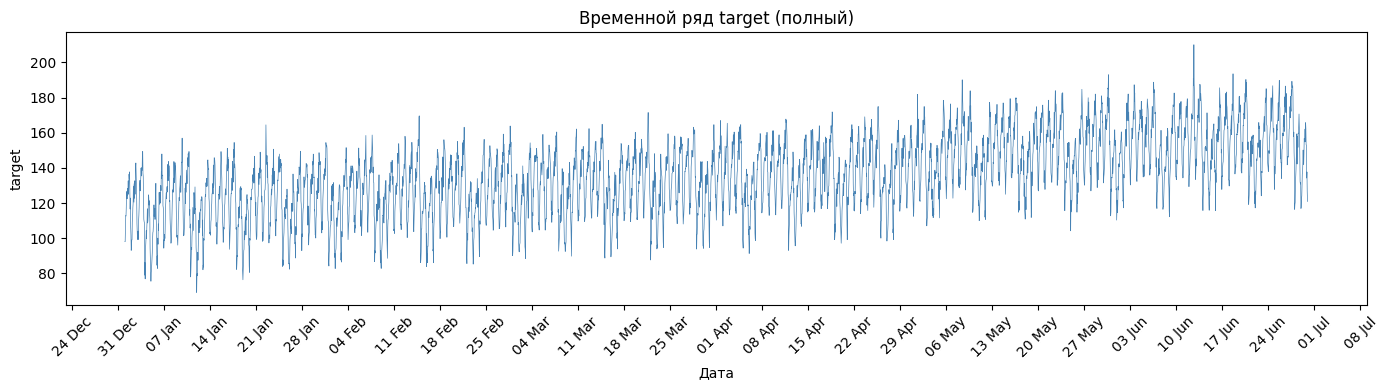

In [4]:
# Базовый график временного ряда
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df["date"], df["target"], linewidth=0.5, color="steelblue")
ax.set_title("Временной ряд target (полный)")
ax.set_xlabel("Дата")
ax.set_ylabel("target")
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURES / "full_series.png", dpi=120)
plt.show()

##### Краткий комментарий по ряду

* **Суточная сезонность** ярко выражена: значения растут утром, достигают пика около 15–17 часов и снижаются к ночи.
* **Недельная сезонность**: в выходные дни (суббота–воскресенье) уровень ряда заметно ниже, чем в будние.
* **Тренд**: наблюдается заметный восходящий тренд от января к июню (средний уровень train ≈ 127, val ≈ 149, test ≈ 155).
* **Выбросы**: отдельные часовые значения могут отклоняться от соседних на 10–20 единиц, но систематических аномалий не видно.
* **Пропуски**: отсутствуют — ряд непрерывный.

## Корректный temporal split (train / validation / test)

**Почему `random split` недопустим для временных рядов:**

При случайном разбиении (`random split`) в обучающую выборку попадают наблюдения из
*будущего* относительно тестовых. Модель получает информацию, которая
на практике ещё не существует, что ведёт к **утечке данных** (data leakage)
и завышенным метрикам. Для временных рядов единственно корректный подход —
**хронологическое разбиение** (temporal split), при котором:

* `train` содержит только самые ранние наблюдения;
* `validation` — следующий по времени блок;
* `test` — самый поздний блок.


In [5]:
# ===========================================================================
# Temporal split: train / validation / test — хронологическое разбиение
# ===========================================================================
# ВАЖНО: random split для временных рядов НЕКОРРЕКТЕН, поскольку при
# случайном перемешивании в train попадают наблюдения из будущего
# относительно val/test, что приводит к утечке данных (data leakage)
# и завышению метрик. Поэтому данные разбиваются строго по времени.
# ===========================================================================

VAL_START  = pd.Timestamp("2025-05-01")
TEST_START = pd.Timestamp("2025-06-01")

train_df = df[df["date"] < VAL_START].copy()
val_df   = df[(df["date"] >= VAL_START) & (df["date"] < TEST_START)].copy()
test_df  = df[df["date"] >= TEST_START].copy()

# Проверяем, что разбиение является строго хронологическим
assert train_df["date"].max() < val_df["date"].min(), "Нарушен temporal split: train/val"
assert val_df["date"].max() < test_df["date"].min(), "Нарушен temporal split: val/test"

print(f"Train:      {len(train_df)} наблюдений  ({train_df['date'].min()} — {train_df['date'].max()})")
print(f"Validation: {len(val_df)} наблюдений  ({val_df['date'].min()} — {val_df['date'].max()})")
print(f"Test:       {len(test_df)} наблюдений  ({test_df['date'].min()} — {test_df['date'].max()})")
print(f"\nРазбиение строго хронологическое (temporal split) — OK")

Train:      2880 наблюдений  (2025-01-01 00:00:00 — 2025-04-30 23:00:00)
Validation: 744 наблюдений  (2025-05-01 00:00:00 — 2025-05-31 23:00:00)
Test:       696 наблюдений  (2025-06-01 00:00:00 — 2025-06-29 23:00:00)

Разбиение строго хронологическое (temporal split) — OK


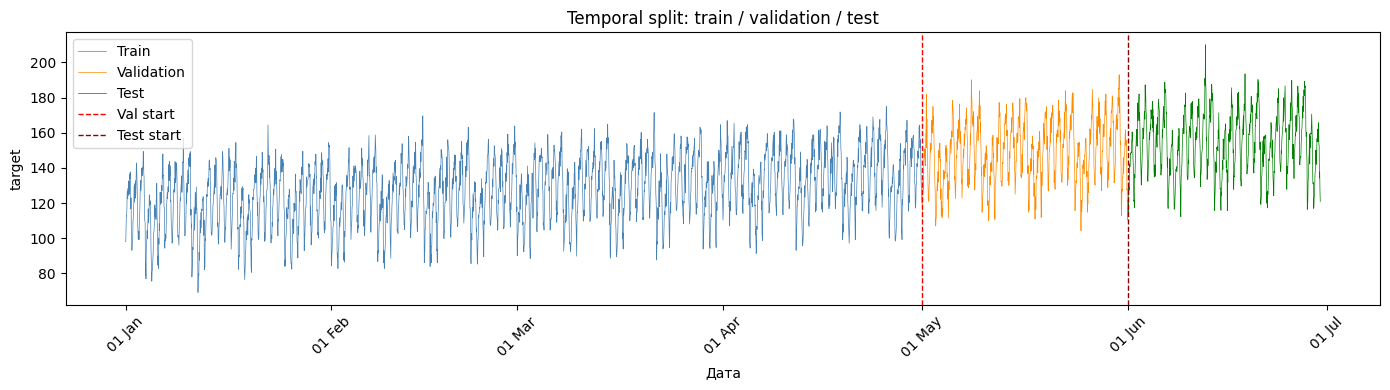

In [6]:
# Визуализация temporal split
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(train_df["date"], train_df["target"],
        linewidth=0.5, color="steelblue", label="Train")
ax.plot(val_df["date"], val_df["target"],
        linewidth=0.5, color="darkorange", label="Validation")
ax.plot(test_df["date"], test_df["target"],
        linewidth=0.5, color="green", label="Test")

# Вертикальные линии на границах split
ax.axvline(VAL_START, color="red", linestyle="--", linewidth=1, label="Val start")
ax.axvline(TEST_START, color="darkred", linestyle="--", linewidth=1, label="Test start")

ax.set_title("Temporal split: train / validation / test")
ax.set_xlabel("Дата")
ax.set_ylabel("target")
ax.legend(loc="upper left")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURES / "series_split.png", dpi=120)
plt.show()

##### Признаки для baseline-моделей (B3 и частично B2)

In [7]:
# Функция построения признаков
def build_features(dataframe: pd.DataFrame) -> pd.DataFrame:
    """Создаёт признаки из столбца target и date.
    Не использует информацию из будущего."""
    out = dataframe.copy()

    # Лаговые признаки
    for lag in [1, 7, 14, 24, 168]:
        out[f"lag_{lag}"] = out["target"].shift(lag)

    # Rolling-признаки (сдвинутые на 1, чтобы не подглядывать)
    shifted = out["target"].shift(1)
    out["rolling_mean_7"] = shifted.rolling(window=7, min_periods=7).mean()
    out["rolling_std_7"]  = shifted.rolling(window=7, min_periods=7).std()

    # Календарные признаки
    out["hour"]        = out["date"].dt.hour
    out["day_of_week"] = out["date"].dt.dayofweek
    out["is_weekend"]  = (out["day_of_week"] >= 5).astype(int)

    return out

# Применяем функцию ко всему датасету целиком, а затем разбиваем заново по тем же датам.
df_feat = build_features(df)

train_feat = df_feat[df_feat["date"] < VAL_START].copy()
val_feat   = df_feat[(df_feat["date"] >= VAL_START) & (df_feat["date"] < TEST_START)].copy()
test_feat  = df_feat[df_feat["date"] >= TEST_START].copy()

# Удаляем строки с NaN, которые возникли из-за лагов/rolling
train_feat = train_feat.dropna()
val_feat   = val_feat.dropna()
test_feat  = test_feat.dropna()

print(f"Train (с признаками): {len(train_feat)}")
print(f"Val   (с признаками): {len(val_feat)}")
print(f"Test  (с признаками): {len(test_feat)}")
print(f"\nПризнаки: {[c for c in train_feat.columns if c not in ('date','target')]}")

Train (с признаками): 2712
Val   (с признаками): 744
Test  (с признаками): 696

Признаки: ['lag_1', 'lag_7', 'lag_14', 'lag_24', 'lag_168', 'rolling_mean_7', 'rolling_std_7', 'hour', 'day_of_week', 'is_weekend']


In [8]:
# Определяем список признаков и готовим массивы X, y
FEATURE_COLS = [
    "lag_1", "lag_7", "lag_14", "lag_24", "lag_168",
    "rolling_mean_7", "rolling_std_7",
    "hour", "day_of_week", "is_weekend",
]

X_train = train_feat[FEATURE_COLS].values
y_train = train_feat["target"].values

X_val = val_feat[FEATURE_COLS].values
y_val = val_feat["target"].values

X_test = test_feat[FEATURE_COLS].values
y_test = test_feat["target"].values

# Масштабирование (StandardScaler) — обучаем ТОЛЬКО на train
scaler_X = StandardScaler()
X_train_sc = scaler_X.fit_transform(X_train)
X_val_sc   = scaler_X.transform(X_val)
X_test_sc  = scaler_X.transform(X_test)

print(f"X_train: {X_train_sc.shape},  y_train: {y_train.shape}")
print(f"X_val:   {X_val_sc.shape},    y_val:   {y_val.shape}")
print(f"X_test:  {X_test_sc.shape},   y_test:  {y_test.shape}")

X_train: (2712, 10),  y_train: (2712,)
X_val:   (744, 10),    y_val:   (744,)
X_test:  (696, 10),   y_test:  (696,)


##### Вспомогательные функции для вычисления метрик

In [9]:
# Функция для вычисления MAE, RMSE, MAPE
def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    """Возвращает словарь с MAE, RMSE и MAPE."""
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100  # в процентах
    return {"mae": round(mae, 4), "rmse": round(rmse, 4), "mape": round(mape, 4)}

# Таблица для сохранения результатов всех экспериментов
runs = []

##### Эксперимент B1 — `naive-last`

Самый простой baseline: прогноз равен **последнему известному значению**
(`lag_1`). Это нижняя граница качества — любая осмысленная модель
должна быть не хуже.


In [10]:
# === Эксперимент B1: naive-last ===
# Прогноз = предыдущее значение (lag_1)
# Для validation берём lag_1 из val_feat (уже сдвинутый на 1 час)
y_pred_b1_val = val_feat["lag_1"].values

# Вычисляем метрики ТОЛЬКО на validation
# (test используется один раз — только для лучшего подхода)
m_b1_val = compute_metrics(y_val, y_pred_b1_val)

print("B1 (naive-last) — Validation:", m_b1_val)

# Сохраняем результат в таблицу runs (test-метрики пока пустые)
runs.append({
    "experiment_id":  "B1",
    "task":           "forecasting",
    "dataset":        "S12-hw-dataset.csv",
    "seed":           SEED,
    "split_summary":  "train<2025-05-01 | val 05-01..05-31 | test>=06-01",
    "window_size":    "—",
    "horizon":        1,
    "model_summary":  "naive-last (y_pred = lag_1)",
    "features_summary": "lag_1",
    "scaler":         "—",
    "optimizer":      "—",
    "lr":             "—",
    "epochs_trained": 0,
    "best_val_mae":   m_b1_val["mae"],
    "best_val_rmse":  m_b1_val["rmse"],
    "best_val_mape":  m_b1_val["mape"],
    "test_mae":       "",
    "test_rmse":      "",
    "test_mape":      "",
    "notes":          "прогноз = последнее известное значение"
})

B1 (naive-last) — Validation: {'mae': 6.576, 'rmse': np.float64(8.3464), 'mape': 4.5199}


## Эксперимент B2 — baseline `moving-average`

Прогноз равен **скользящему среднему** за последние `k` часов.
Выбираем `k = 24` (одни сутки), что позволяет сгладить
внутридневную вариацию и использовать суточный паттерн.


In [11]:
# === Эксперимент B2: moving-average ===
# Прогноз = скользящее среднее за MA_WINDOW предшествующих часов
MA_WINDOW = 24  # размер окна скользящего среднего (одни сутки)

# Строим скользящее среднее по всему ряду со сдвигом shift(1),
# чтобы текущее значение не попало в среднее
ma_series = df["target"].shift(1).rolling(window=MA_WINDOW, min_periods=MA_WINDOW).mean()

# Извлекаем прогнозы ТОЛЬКО для validation
y_pred_b2_val = ma_series.loc[val_feat.index].values

# Вычисляем метрики ТОЛЬКО на validation
m_b2_val = compute_metrics(y_val, y_pred_b2_val)

print(f"B2 (moving-average, k={MA_WINDOW}) — Validation:", m_b2_val)

# Сохраняем результат (test-метрики пока пустые)
runs.append({
    "experiment_id":  "B2",
    "task":           "forecasting",
    "dataset":        "S12-hw-dataset.csv",
    "seed":           SEED,
    "split_summary":  "train<2025-05-01 | val 05-01..05-31 | test>=06-01",
    "window_size":    MA_WINDOW,
    "horizon":        1,
    "model_summary":  f"moving-average (k={MA_WINDOW})",
    "features_summary": f"rolling_mean_{MA_WINDOW}",
    "scaler":         "—",
    "optimizer":      "—",
    "lr":             "—",
    "epochs_trained": 0,
    "best_val_mae":   m_b2_val["mae"],
    "best_val_rmse":  m_b2_val["rmse"],
    "best_val_mape":  m_b2_val["mape"],
    "test_mae":       "",
    "test_rmse":      "",
    "test_mape":      "",
    "notes":          f"скользящее среднее за {MA_WINDOW} часов"
})

B2 (moving-average, k=24) — Validation: {'mae': 13.4059, 'rmse': np.float64(16.2473), 'mape': 9.3011}


##### Эксперимент B3 — `ridge-lag-features`

`Ridge`-регрессия на лаговых, rolling- и календарных признаках.
Масштабирование признаков обучено **только на train**.


In [12]:
# === Эксперимент B3: ridge-lag-features ===
ridge = Ridge(alpha=1.0, random_state=SEED)
ridge.fit(X_train_sc, y_train)  # обучаем только на train

# Прогнозы ТОЛЬКО на validation
y_pred_b3_val = ridge.predict(X_val_sc)

# Метрики ТОЛЬКО на validation
m_b3_val = compute_metrics(y_val, y_pred_b3_val)

print("B3 (ridge-lag-features) — Validation:", m_b3_val)

# Сохраняем результат (test-метрики пока пустые)
runs.append({
    "experiment_id":  "B3",
    "task":           "forecasting",
    "dataset":        "S12-hw-dataset.csv",
    "seed":           SEED,
    "split_summary":  "train<2025-05-01 | val 05-01..05-31 | test>=06-01",
    "window_size":    "—",
    "horizon":        1,
    "model_summary":  "Ridge(alpha=1.0)",
    "features_summary": ", ".join(FEATURE_COLS),
    "scaler":         "StandardScaler (fit on train)",
    "optimizer":      "—",
    "lr":             "—",
    "epochs_trained": 0,
    "best_val_mae":   m_b3_val["mae"],
    "best_val_rmse":  m_b3_val["rmse"],
    "best_val_mape":  m_b3_val["mape"],
    "test_mae":       "",
    "test_rmse":      "",
    "test_mape":      "",
    "notes":          "L2-регуляризованная линейная регрессия на lag/rolling/calendar признаках"
})

B3 (ridge-lag-features) — Validation: {'mae': 5.5324, 'rmse': np.float64(6.9897), 'mape': 3.7116}


##### Эксперимент R1 — `gru-forecast`

Подготовка оконного представления

Для GRU формируем **последовательности фиксированной длины** `WINDOW_SIZE`.
Каждый пример = окно из `WINDOW_SIZE` последовательных значений,
а целевая переменная = следующее значение после окна.


In [13]:
# Гиперпараметры GRU
WINDOW_SIZE = 24 # окно в один день (24 часа)
HIDDEN_SIZE = 32 # размер скрытого состояния GRU
NUM_LAYERS  = 1 # одна рекуррентная «прослойка»
BATCH_SIZE  = 64 # размер мини-батча
MAX_EPOCHS  = 30 # максимальное число эпох
LR          = 1e-3 # learning rate оптимизатора Adam
PATIENCE    = 5 # число эпох без улучшения для ранней остановки

In [14]:
# Масштабирование таргета для GRU
scaler_target = StandardScaler()

# Извлекаем полный ряд target в массив
full_target = df["target"].values.reshape(-1, 1)

# Обучаем scaler на train (первые len(train_df) значений)
scaler_target.fit(full_target[:len(train_df)])

# Масштабируем весь ряд (train + val + test)
target_scaled = scaler_target.transform(full_target).flatten()

print(f"Среднее (train): {scaler_target.mean_[0]:.2f}")
print(f"Std     (train): {scaler_target.scale_[0]:.2f}")

Среднее (train): 127.46
Std     (train): 18.23


In [15]:
# PyTorch Dataset для создания скользящих окон
class TimeSeriesDataset(Dataset):
    """Датасет скользящих окон для задачи прогнозирования."""

    def __init__(self, data: np.ndarray, window_size: int):
        """
        data        — одномерный массив масштабированных значений.
        window_size — длина входного окна.
        """
        self.data = data
        self.window_size = window_size

    def __len__(self):
        # Число корректных окон (каждому окну нужен ещё один шаг вперёд для y)
        return len(self.data) - self.window_size

    def __getitem__(self, idx):
        # X = окно [idx, idx+window_size),  y = значение в idx+window_size
        x = self.data[idx : idx + self.window_size].astype(np.float32)
        y = self.data[idx + self.window_size].astype(np.float32)
        # Добавляем размерность признака: (W,) -> (W, 1) для GRU
        return torch.tensor(x).unsqueeze(-1), torch.tensor(y)

# Определяем индексы для каждой части
n_train = len(train_df)
n_val   = len(val_df)
n_test  = len(test_df)

# Датасет для train: окна, целиком лежащие внутри train
train_ds = TimeSeriesDataset(target_scaled[:n_train], WINDOW_SIZE)

# Датасет для val: окна заканчивающиеся в val-области
#   Начало данных = n_train - WINDOW_SIZE, чтобы первые окна
#   могли «заглянуть» в конец train (это прошлое, не утечка)
val_data = target_scaled[n_train - WINDOW_SIZE : n_train + n_val]
val_ds   = TimeSeriesDataset(val_data, WINDOW_SIZE)

# Датасет для test: аналогично
test_data = target_scaled[n_train + n_val - WINDOW_SIZE : n_train + n_val + n_test]
test_ds   = TimeSeriesDataset(test_data, WINDOW_SIZE)

print(f"Train DS: {len(train_ds)} примеров")
print(f"Val   DS: {len(val_ds)} примеров")
print(f"Test  DS: {len(test_ds)} примеров")

# DataLoader'ы
# ВАЖНО: shuffle=False для всех loader'ов — для временных рядов
# перемешивание не используется, чтобы сохранить хронологический порядок
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

Train DS: 2856 примеров
Val   DS: 744 примеров
Test  DS: 696 примеров


##### Архитектура модели GRU

In [16]:
# Определяем модель GRUForecaster
class GRUForecaster(nn.Module):
    """Простая GRU-модель для прогноза временного ряда."""

    def __init__(self, input_size: int = 1,
                 hidden_size: int = 32,
                 num_layers: int = 1):
        super().__init__()
        # Рекуррентный слой GRU
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,     # вход: (batch, seq, features)
        )
        # Линейный слой для преобразования скрытого состояния в прогноз
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x: (batch, seq_len, 1)
        # out: (batch, seq_len, hidden_size)
        # h_n: (num_layers, batch, hidden_size)
        out, h_n = self.gru(x)
        # Берём скрытое состояние на последнем временном шаге
        last_hidden = h_n[-1]           # (batch, hidden_size)
        prediction = self.fc(last_hidden)  # (batch, 1)
        return prediction.squeeze(-1)      # (batch,)

# Создаём модель, функцию потерь и оптимизатор
model = GRUForecaster(
    input_size=1,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
).to(DEVICE)

criterion = nn.MSELoss()                          # среднеквадратичная ошибка
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# Подсчитаем число параметров модели
n_params = sum(p.numel() for p in model.parameters())
print(f"Модель GRU: {n_params} параметров")
print(model)

Модель GRU: 3393 параметров
GRUForecaster(
  (gru): GRU(1, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)


##### Цикл обучения GRU (с ранней остановкой)

In [17]:
# Функция обучения одной эпохи
def train_one_epoch(model, loader, criterion, optimizer, device):
    """Один проход по train-loader, возвращает средний loss."""
    model.train()
    total_loss = 0.0
    n_batches  = 0
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        preds = model(X_batch)
        loss  = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        n_batches  += 1
    return total_loss / n_batches

# Функция оценки на заданном loader (без обновления весов)
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    """Средний loss на val/test без обновления весов."""
    model.eval()
    total_loss = 0.0
    n_batches  = 0
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        preds = model(X_batch)
        loss  = criterion(preds, y_batch)
        total_loss += loss.item()
        n_batches  += 1
    return total_loss / n_batches

# Функция получения прогнозов на loader в исходном масштабе
@torch.no_grad()
def predict(model, loader, device, scaler):
    """Возвращает numpy-массив прогнозов в оригинальном масштабе."""
    model.eval()
    preds_scaled = []
    for X_batch, _ in loader:
        X_batch = X_batch.to(device)
        out = model(X_batch)
        preds_scaled.append(out.cpu().numpy())
    preds_scaled = np.concatenate(preds_scaled)
    # Обратное масштабирование
    preds_original = scaler.inverse_transform(preds_scaled.reshape(-1, 1)).flatten()
    return preds_original

In [18]:
# Основной цикл обучения с ранней остановкой (early stopping)
history = {"epoch": [], "train_loss": [], "val_loss": []}

best_val_loss = float("inf")
patience_counter = 0
best_state_dict = None

print("Эпоха | Train Loss | Val Loss")
print("-" * 36)

for epoch in range(1, MAX_EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss   = evaluate(model, val_loader, criterion, DEVICE)

    history["epoch"].append(epoch)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    improved = ""
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        # Сохраняем лучшие веса модели
        best_state_dict = {k: v.clone() for k, v in model.state_dict().items()}
        improved = " *"
    else:
        patience_counter += 1

    print(f"  {epoch:3d}  |  {train_loss:.6f}  |  {val_loss:.6f}{improved}")

    if patience_counter >= PATIENCE:
        print(f"\nРанняя остановка на эпохе {epoch} (patience={PATIENCE})")
        break

# Загружаем лучшие веса
model.load_state_dict(best_state_dict)

# Число эпох, на которых было обучение
epochs_trained = epoch
print(f"\nЛучший val_loss (MSE, масштабированный): {best_val_loss:.6f}")
print(f"Обучено эпох: {epochs_trained}")

Эпоха | Train Loss | Val Loss
------------------------------------
    1  |  0.768026  |  1.156489 *
    2  |  0.429599  |  0.483648 *
    3  |  0.257037  |  0.278375 *
    4  |  0.185452  |  0.198170 *
    5  |  0.168152  |  0.189127 *
    6  |  0.161214  |  0.185494 *
    7  |  0.157381  |  0.182916 *
    8  |  0.154676  |  0.181476 *
    9  |  0.152678  |  0.180836 *
   10  |  0.151131  |  0.180707 *
   11  |  0.149822  |  0.180881
   12  |  0.148594  |  0.181216
   13  |  0.147324  |  0.181624
   14  |  0.145873  |  0.182064
   15  |  0.143992  |  0.182534

Ранняя остановка на эпохе 15 (patience=5)

Лучший val_loss (MSE, масштабированный): 0.180707
Обучено эпох: 15


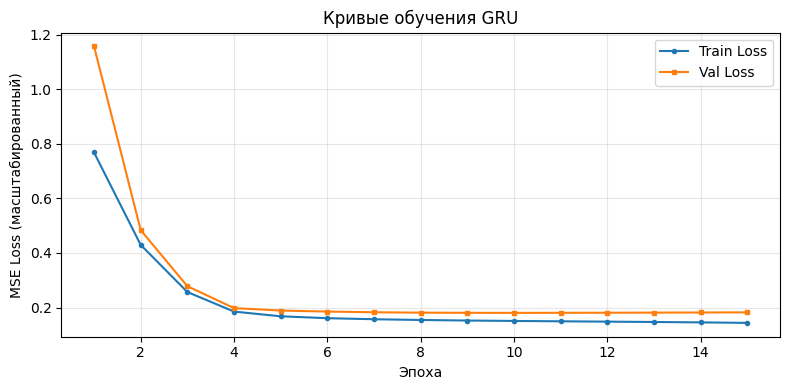

In [19]:
# Кривые обучения (train/val loss)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history["epoch"], history["train_loss"], label="Train Loss", marker="o", markersize=3)
ax.plot(history["epoch"], history["val_loss"],   label="Val Loss",   marker="s", markersize=3)
ax.set_xlabel("Эпоха")
ax.set_ylabel("MSE Loss (масштабированный)")
ax.set_title("Кривые обучения GRU")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES / "gru_learning_curves.png", dpi=120)
plt.show()

In [20]:
# === Эксперимент R1: gru-forecast — оценка на validation ===
# Прогнозы GRU ТОЛЬКО на validation (в оригинальном масштабе)
y_pred_r1_val = predict(model, val_loader, DEVICE, scaler_target)

# Обрезаем y_val до длины прогнозов
# (первые WINDOW_SIZE-1 значений val не имеют полного окна)
y_val_gru = y_val[:len(y_pred_r1_val)]

# Метрики ТОЛЬКО на validation
m_r1_val = compute_metrics(y_val_gru, y_pred_r1_val)

print("R1 (gru-forecast) — Validation:", m_r1_val)

# Сохраняем в runs (test-метрики пока пустые)
runs.append({
    "experiment_id":  "R1",
    "task":           "forecasting",
    "dataset":        "S12-hw-dataset.csv",
    "seed":           SEED,
    "split_summary":  "train<2025-05-01 | val 05-01..05-31 | test>=06-01",
    "window_size":    WINDOW_SIZE,
    "horizon":        1,
    "model_summary":  f"GRU(hidden={HIDDEN_SIZE}, layers={NUM_LAYERS})",
    "features_summary": f"raw target (window={WINDOW_SIZE})",
    "scaler":         "StandardScaler (fit on train target)",
    "optimizer":      "Adam",
    "lr":             LR,
    "epochs_trained": epochs_trained,
    "best_val_mae":   m_r1_val["mae"],
    "best_val_rmse":  m_r1_val["rmse"],
    "best_val_mape":  m_r1_val["mape"],
    "test_mae":       "",
    "test_rmse":      "",
    "test_mape":      "",
    "notes":          f"GRU, window={WINDOW_SIZE}, hidden={HIDDEN_SIZE}, epochs={epochs_trained}, patience={PATIENCE}"
})

R1 (gru-forecast) — Validation: {'mae': 6.1486, 'rmse': np.float64(7.6955), 'mape': 4.1717}


##### Сравнение результатов

In [23]:
# Сводная таблица по validation
runs_df = pd.DataFrame(runs)

# Приводим test-колонки к float (они были пустыми строками)
for col in ["test_mae", "test_rmse", "test_mape"]:
    runs_df[col] = pd.to_numeric(runs_df[col], errors="coerce")

print("=== Результаты на VALIDATION ===")
print(runs_df[["experiment_id", "model_summary",
               "best_val_mae", "best_val_rmse", "best_val_mape"]].to_string(index=False))
print()

# Определяем лучшую модель по val_mae
best_idx = runs_df["best_val_mae"].astype(float).idxmin()
best_id  = runs_df.loc[best_idx, "experiment_id"]
print(f"Лучший подход по val_MAE: {best_id}")
print()

# ===========================================================================
# Финальная оценка лучшей модели на TEST (однократно!)
# По условию задания test используется ТОЛЬКО для лучшего подхода.
# ===========================================================================
if best_id == "B1":
    y_pred_best_test = test_feat["lag_1"].values
    y_true_best_test = y_test
elif best_id == "B2":
    y_pred_best_test = ma_series.loc[test_feat.index].values
    y_true_best_test = y_test
elif best_id == "B3":
    y_pred_best_test = ridge.predict(X_test_sc)
    y_true_best_test = y_test
elif best_id == "R1":
    y_pred_best_test = predict(model, test_loader, DEVICE, scaler_target)
    y_true_best_test = y_test[:len(y_pred_best_test)]

m_best_test = compute_metrics(y_true_best_test, y_pred_best_test)

# Записываем test-метрики ТОЛЬКО для лучшего подхода
runs_df.at[best_idx, "test_mae"]  = m_best_test["mae"]
runs_df.at[best_idx, "test_rmse"] = m_best_test["rmse"]
runs_df.at[best_idx, "test_mape"] = m_best_test["mape"]

print(f"=== Финальный результат на TEST ({best_id}) ===")
print(f"  MAE:  {m_best_test['mae']}")
print(f"  RMSE: {m_best_test['rmse']}")
print(f"  MAPE: {m_best_test['mape']}%")

=== Результаты на VALIDATION ===
experiment_id               model_summary  best_val_mae  best_val_rmse  best_val_mape
           B1 naive-last (y_pred = lag_1)        6.5760         8.3464         4.5199
           B2       moving-average (k=24)       13.4059        16.2473         9.3011
           B3            Ridge(alpha=1.0)        5.5324         6.9897         3.7116
           R1    GRU(hidden=32, layers=1)        6.1486         7.6955         4.1717

Лучший подход по val_MAE: B3

=== Финальный результат на TEST (B3) ===
  MAE:  5.1446
  RMSE: 6.434
  MAPE: 3.3032%


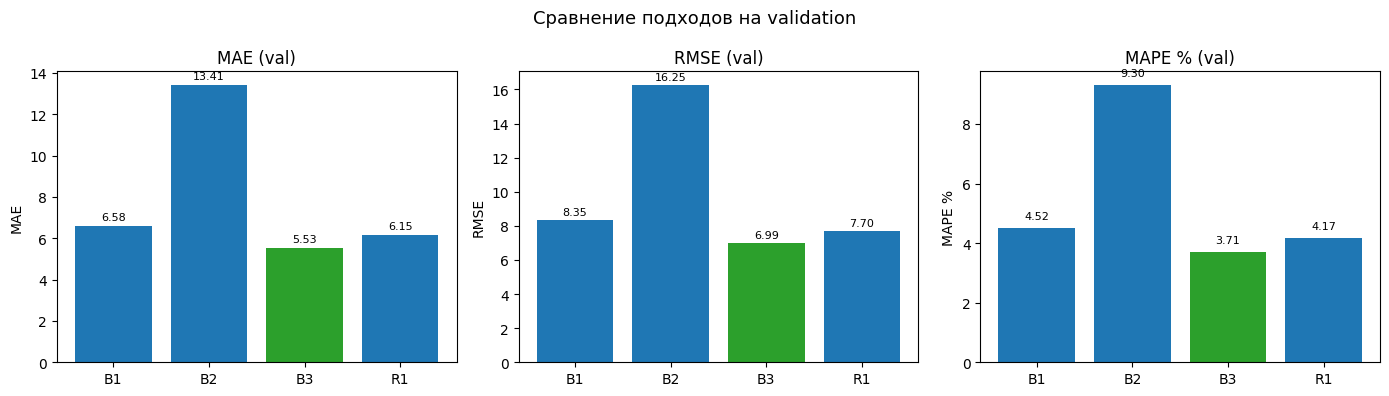

In [24]:
# Столбчатая диаграмма сравнения подходов по val_MAE
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, metric, title in zip(axes,
                              ["best_val_mae", "best_val_rmse", "best_val_mape"],
                              ["MAE (val)", "RMSE (val)", "MAPE % (val)"]):
    vals = runs_df[metric].astype(float)
    colors = ["#2ca02c" if i == best_idx else "#1f77b4" for i in range(len(vals))]
    ax.bar(runs_df["experiment_id"], vals, color=colors)
    ax.set_title(title)
    ax.set_ylabel(title.split("(")[0].strip())
    for i, v in enumerate(vals):
        ax.text(i, v + 0.3, f"{v:.2f}", ha="center", fontsize=8)

plt.suptitle("Сравнение подходов на validation", fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES / "baselines_compare.png", dpi=120)
plt.show()

##### Визуализация прогноза лучшей модели на test

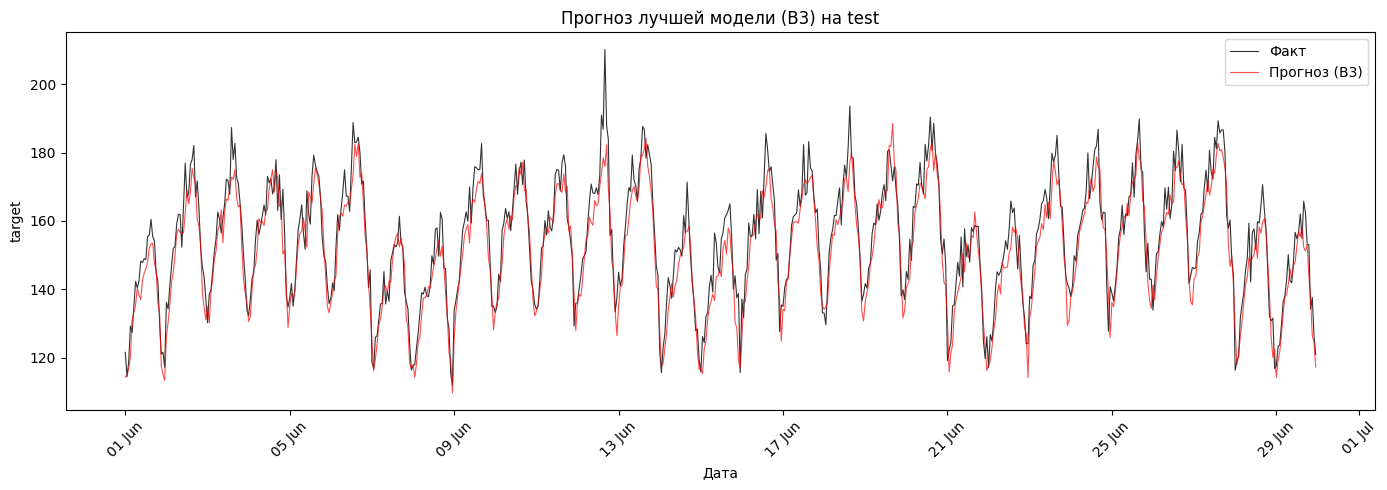

In [25]:
# Визуализация прогноза лучшей модели на test
# (y_pred_best_test и y_true_best_test вычислены в предыдущей ячейке)
dates_plot = test_feat["date"].values[:len(y_pred_best_test)]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(dates_plot, y_true_best_test, linewidth=0.8, color="black", label="Факт", alpha=0.8)
ax.plot(dates_plot, y_pred_best_test, linewidth=0.8, color="red", label=f"Прогноз ({best_id})", alpha=0.7)
ax.set_title(f"Прогноз лучшей модели ({best_id}) на test")
ax.set_xlabel("Дата")
ax.set_ylabel("target")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURES / "best_forecast_test.png", dpi=120)
plt.show()

##### Сохранение артефактов

In [26]:
# Сохраняем таблицу прогонов runs.csv
runs_df.to_csv(ARTIFACTS / "runs.csv", index=False)
print("Сохранено: artifacts/runs.csv")

# Сохраняем лучшую GRU-модель (веса) и её конфигурацию
torch.save(model.state_dict(), ARTIFACTS / "best_gru.pt")
print("Сохранено: artifacts/best_gru.pt")

gru_config = {
    "input_size":  1,
    "hidden_size": HIDDEN_SIZE,
    "num_layers":  NUM_LAYERS,
    "window_size": WINDOW_SIZE,
    "scaler_mean": float(scaler_target.mean_[0]),
    "scaler_std":  float(scaler_target.scale_[0]),
    "seed":        SEED,
    "lr":          LR,
    "batch_size":  BATCH_SIZE,
    "epochs_trained": epochs_trained,
    "best_val_loss":  best_val_loss,
}
with open(ARTIFACTS / "best_gru_config.json", "w") as f:
    json.dump(gru_config, f, indent=2, ensure_ascii=False)
print("Сохранено: artifacts/best_gru_config.json")

# Сохраняем историю обучения GRU
pd.DataFrame(history).to_csv(ARTIFACTS / "gru_history.csv", index=False)
print("Сохранено: artifacts/gru_history.csv")

print("\nВсе артефакты сохранены в папку artifacts/")

Сохранено: artifacts/runs.csv
Сохранено: artifacts/best_gru.pt
Сохранено: artifacts/best_gru_config.json
Сохранено: artifacts/gru_history.csv

Все артефакты сохранены в папку artifacts/


##### Выводы

* **B1 (naive-last)** — простейший baseline; использует только последнее значение.
* **B2 (moving-average)** — усреднение за сутки сглаживает шум, но не учитывает внутридневные паттерны, из-за чего проигрывает Ridge.
* **B3 (ridge-lag-features)** — учёт лаговых, rolling и календарных признаков позволяет модели «видеть» суточную и недельную структуру.
* **R1 (gru-forecast)** — GRU обрабатывает целое окно последовательно и может улавливать нелинейные зависимости, но на коротком ряде не всегда превосходит Ridge.

